In [30]:
import numpy as np
import librosa
import os


def pre_emphasis(signal, alpha=0.97):
    return np.append(signal[0], signal[1:] - alpha * signal[:-1])



def extract_features(audio_path, n_mfcc=20):
    signal, sr = librosa.load(audio_path, sr=None)

    signal = pre_emphasis(signal)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=512,
        hop_length=160
    )

    T = mfcc.shape[1]

    width = min(9, T if T % 2 == 1 else T - 1)
    if width < 3:
        width = 3 

    delta = librosa.feature.delta(mfcc, width=width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=width)

    features = np.vstack((mfcc, delta, delta2))

    return features.T


def parse_filename(filename):

    parts = filename.replace(".wav", "").split("_")

    digit = int(parts[0])
    speaker = int(parts[1].replace("speaker", ""))

    return digit, speaker



def load_dataset(folder_path):
    data = []

    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            path = os.path.join(folder_path, file)

            digit, speaker = parse_filename(file)
            features = extract_features(path)

            data.append({
                "features": features,
                "digit": digit,
                "speaker": speaker
            })

    return data




def split_data(data):
    train = []
    val = []
    test = []

    speaker_1_to_5 = [item for item in data if item["speaker"] <= 5]
    test = [item for item in data if item["speaker"] == 6]

    import random
    random.seed(42)
    random.shuffle(speaker_1_to_5)

    split_idx = int(0.8 * len(speaker_1_to_5))
    train = speaker_1_to_5[:split_idx]
    val = speaker_1_to_5[split_idx:]

    return train, val, test


def compute_normalization(train_data):
    all_features = []

    for item in train_data:
        all_features.append(item["features"])

    all_features = np.vstack(all_features)

    mean = np.mean(all_features, axis=0)
    std = np.std(all_features, axis=0) + 1e-8

    return mean, std


def normalize(data, mean, std):
    for item in data:
        item["features"] = (item["features"] - mean) / std
    return data

def prepare_dataset(folder_path):
    data = load_dataset(folder_path)
 
    train, val, test = split_data(data)
 
    mean, std = compute_normalization(train)
 
    train = normalize(train, mean, std)
    val   = normalize(val,   mean, std)
    test  = normalize(test,  mean, std)
 
    return train, val, test, mean, std


def extract_for_inference(audio_file, mean, std):
    features = extract_features(audio_file)
    return (features - mean) / std



if __name__ == "__main__":
    folder = "/Users/sidharthadurgam/Downloads/recordings"   

    train_data, val_data, test_data, mean, std = prepare_dataset(folder)

    print("Training samples:", len(train_data))
    print("Testing samples:", len(test_data))
    print(len(val_data))

   

Training samples: 2000
Testing samples: 500
500


In [16]:
zero_data = []
one_data = []
two_data = []
three_data = []
four_data = []
five_data = []
six_data = []
seven_data = []
eight_data = []
nine_data = []
for i in range(len(train_data)):
    
    if train_data[i]['digit'] ==0:
        zero_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==1:
        one_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==2:
        two_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==3:
        three_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==4:
        four_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==5:
        five_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==6:
        six_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==7:
        seven_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==8:
        eight_data.append(train_data[i]['features'])
    elif train_data[i]['digit'] ==9:
        nine_data.append(train_data[i]['features'])


X_0 = np.vstack(zero_data)
X_1 = np.vstack(one_data)
X_2 = np.vstack(two_data)
X_3 = np.vstack(three_data)
X_4 = np.vstack(four_data)
X_5 = np.vstack(five_data)  
X_6 = np.vstack(six_data)
X_7 = np.vstack(seven_data)
X_8 = np.vstack(eight_data)
X_9 = np.vstack(nine_data)



GMM

In [17]:
import numpy as np


class GaussianMixtureModel:


    def __init__(self, n_components=2, max_iter=100, tol=1e-6, random_state=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.pi = None
        self.mu = None
        self.sigma = None
        self.log_likelihood_history = []

    def _ensure_2d(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return X


    def _initialize_parameters(self, X):
        X = self._ensure_2d(X)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)

        self.pi = np.ones(self.n_components) / self.n_components

        random_indices = rng.choice(n_samples, self.n_components, replace=False)
        self.mu = X[random_indices]


        self.sigma = np.ones((self.n_components, n_features)) + 1e-6

        return None


    def _log_gaussian_pdf(self, X, mu, sigma):
        n_features = X.shape[1]
        
        log_const = -0.5 * n_features * np.log(2 * np.pi) - 0.5 * np.sum(np.log(sigma))
        

        diff = X - mu
        log_exponent = -0.5 * np.sum((diff ** 2) / sigma, axis=1)
        
        return log_const + log_exponent

    def _e_step(self, X):
        n_samples = X.shape[0]
        
        log_weighted_probs = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            log_prior = np.log(self.pi[k])
            log_likelihood = self._log_gaussian_pdf(X, self.mu[k], self.sigma[k])
            log_weighted_probs[:, k] = log_prior + log_likelihood


        max_log_vals = np.max(log_weighted_probs, axis=1, keepdims=True)
        
        log_sum_exp = max_log_vals + np.log(np.sum(np.exp(log_weighted_probs - max_log_vals), axis=1, keepdims=True))

        log_responsibilities = log_weighted_probs - log_sum_exp
        
        responsibilities = np.exp(log_responsibilities)

        return responsibilities

    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape

        N_k = np.sum(responsibilities, axis=0)

        self.pi = N_k / n_samples

        self.mu = np.zeros((self.n_components, n_features))
        self.sigma = np.zeros((self.n_components, n_features)) 

        for k in range(self.n_components):
            gamma_k = responsibilities[:, k]

            self.mu[k] = np.sum(gamma_k.reshape(-1, 1) * X, axis=0) / N_k[k]

            diff = X - self.mu[k]
            self.sigma[k] = np.sum(gamma_k.reshape(-1, 1) * (diff ** 2), axis=0) / N_k[k]

            self.sigma[k] += 1e-6

        return None

    def _compute_log_likelihood(self, X):
        n_samples = X.shape[0]
        log_weighted_probs = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            log_prior = np.log(self.pi[k])
            log_likelihood = self._log_gaussian_pdf(X, self.mu[k], self.sigma[k])
            log_weighted_probs[:, k] = log_prior + log_likelihood

        max_log_vals = np.max(log_weighted_probs, axis=1, keepdims=True)
        log_sum_exp = max_log_vals + np.log(np.sum(np.exp(log_weighted_probs - max_log_vals), axis=1, keepdims=True))
        
        return np.sum(log_sum_exp)


    def fit(self, X):
        X = self._ensure_2d(X)
        self._initialize_parameters(X)

        prev_log_likelihood = -np.inf

        for iteration in range(self.max_iter):

            responsibilities = self._e_step(X)

            self._m_step(X, responsibilities)

            current_log_likelihood = self._compute_log_likelihood(X)
            self.log_likelihood_history.append(current_log_likelihood)

            imp = current_log_likelihood - prev_log_likelihood
            if imp >= 0 and imp < self.tol:
                break

            prev_log_likelihood = current_log_likelihood

        return self

    def predict_proba(self, X):
        X = self._ensure_2d(X)
        return self._e_step(X)

    def predict(self, X):
        X = self._ensure_2d(X)
        return np.argmax(self._e_step(X), axis=1)


In [18]:
import numpy as np

raw_variables = {
    0: X_0, 1: X_1, 2: X_2, 3: X_3, 4: X_4, 
    5: X_5, 6: X_6, 7: X_7, 8: X_8, 9: X_9
}

clean_training_matrices = {}

for digit, data in raw_variables.items():

        clean_data = np.array(data, dtype=np.float32)
        clean_training_matrices[digit] = clean_data
        print(f"Digit {digit}:{clean_data.shape}")
        



trained_gmms = {}

for digit, X_train in clean_training_matrices.items():
    print(f"Training GMM for digit {digit}...")
    
    gmm = GaussianMixtureModel(n_components=8, max_iter=100, tol=1e-6, random_state=42)
    
    gmm.fit(X_train)
    
    trained_gmms[digit] = gmm



Digit 0:(5397, 60)
Digit 1:(4076, 60)
Digit 2:(4321, 60)
Digit 3:(4388, 60)
Digit 4:(4199, 60)
Digit 5:(4587, 60)
Digit 6:(4882, 60)
Digit 7:(5134, 60)
Digit 8:(4231, 60)
Digit 9:(5195, 60)
Training GMM for digit 0...
Training GMM for digit 1...
Training GMM for digit 2...
Training GMM for digit 3...
Training GMM for digit 4...
Training GMM for digit 5...
Training GMM for digit 6...
Training GMM for digit 7...
Training GMM for digit 8...
Training GMM for digit 9...


In [19]:
def predict_digit(test_features, gmm_models):

    best_digit = None
    max_log_likelihood = -np.inf
    
    for digit, gmm in gmm_models.items():
        score = gmm._compute_log_likelihood(test_features)
        
        if score > max_log_likelihood:
            max_log_likelihood = score
            best_digit = digit
            
    return best_digit

In [20]:

true_labels = []
predicted_labels = []




for data_point in test_data:
    
    actual_digit = data_point['digit']
    features = data_point['features']
    

    prediction = predict_digit(features, trained_gmms)
    

    true_labels.append(actual_digit)
    predicted_labels.append(prediction)

===== GMM RESULTS =====
Validation Accuracy : 97.40%
Test Accuracy       : 91.60%

GMM Per-Digit Validation Accuracy:
  Digit 0: 100.00%
  Digit 1: 100.00%
  Digit 2: 95.12%
  Digit 3: 88.89%
  Digit 4: 100.00%
  Digit 5: 98.00%
  Digit 6: 92.45%
  Digit 7: 100.00%
  Digit 8: 100.00%
  Digit 9: 98.00%

GMM Per-Digit Test Accuracy:
  Digit 0: 98.00%
  Digit 1: 100.00%
  Digit 2: 98.00%
  Digit 3: 96.00%
  Digit 4: 98.00%
  Digit 5: 100.00%
  Digit 6: 46.00%
  Digit 7: 100.00%
  Digit 8: 100.00%
  Digit 9: 80.00%


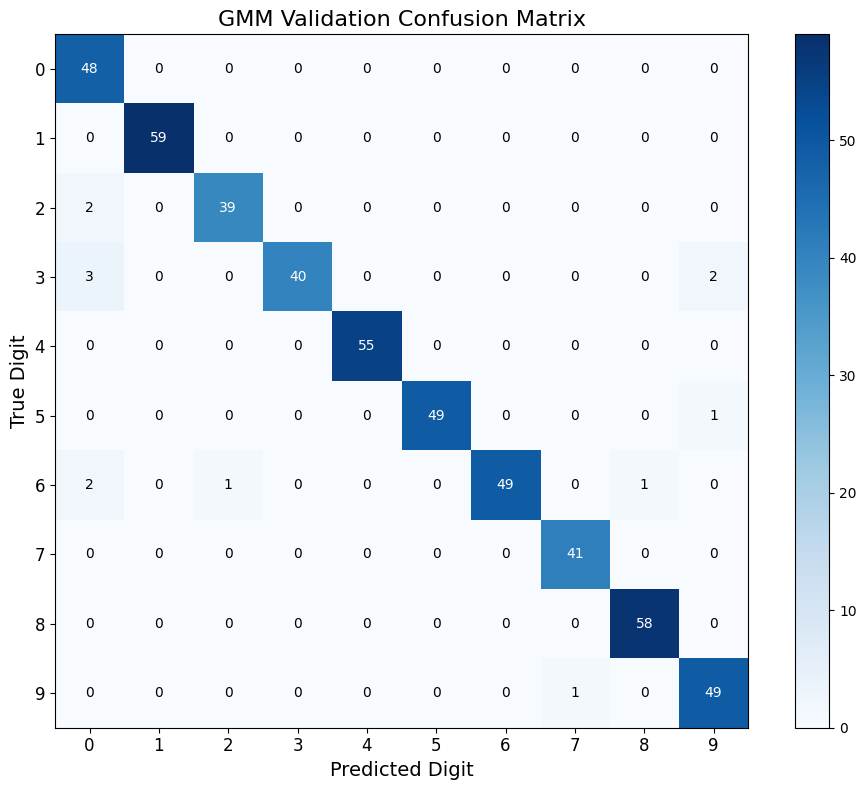

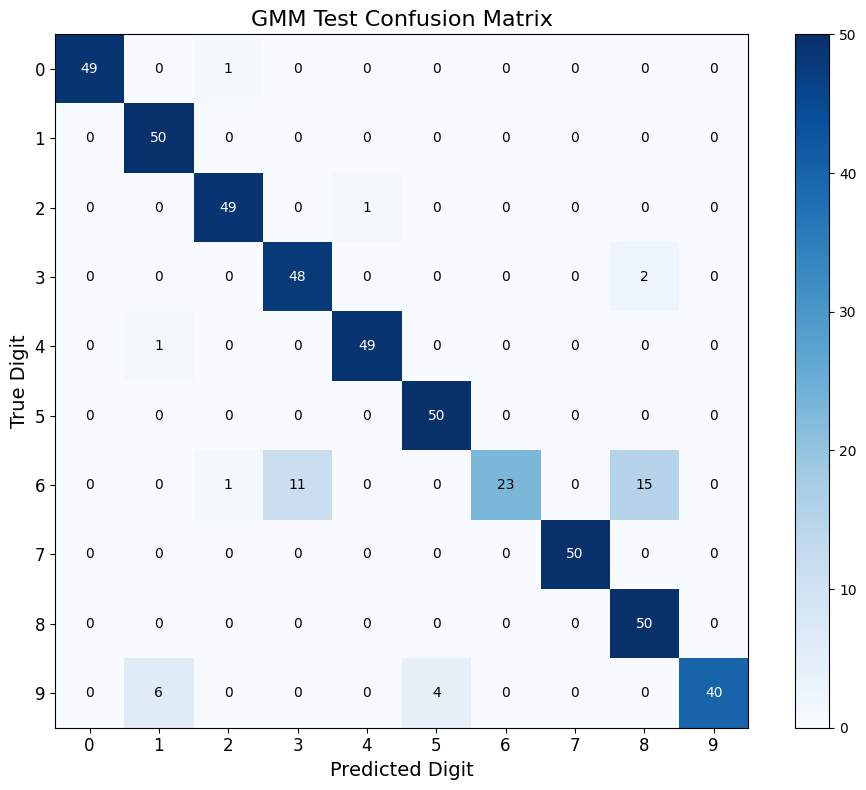

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate(data, predict_fn, models):
    true_labels      = []
    predicted_labels = []
    for item in data:
        true_labels.append(item["digit"])
        predicted_labels.append(predict_fn(item["features"], models))
    num_classes = 10
    conf_matrix = [[0] * num_classes for _ in range(num_classes)]
    for true, pred in zip(true_labels, predicted_labels):
        conf_matrix[true][pred] += 1
    correct = sum(1 for t, p in zip(true_labels, predicted_labels) if t == p)
    accuracy = correct / len(true_labels)
    return accuracy, conf_matrix


def plot_confusion_matrix(conf_matrix, title):
    cm = np.array(conf_matrix)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels([str(i) for i in range(10)], fontsize=12)
    ax.set_yticklabels([str(i) for i in range(10)], fontsize=12)
    ax.set_xlabel("Predicted Digit", fontsize=14)
    ax.set_ylabel("True Digit", fontsize=14)
    ax.set_title(title, fontsize=16)
    thresh = cm.max() / 2.0
    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()



gmm_val_acc,  gmm_val_cm  = evaluate(val_data,  predict_digit, trained_gmms)
gmm_test_acc, gmm_test_cm = evaluate(test_data, predict_digit, trained_gmms)

print("===== GMM RESULTS =====")
print(f"Validation Accuracy : {gmm_val_acc  * 100:.2f}%")
print(f"Test Accuracy       : {gmm_test_acc * 100:.2f}%")

print("\nGMM Per-Digit Validation Accuracy:")
for digit in range(10):
    total = sum(gmm_val_cm[digit])
    if total > 0:
        print(f"  Digit {digit}: {gmm_val_cm[digit][digit] / total * 100:.2f}%")

print("\nGMM Per-Digit Test Accuracy:")
for digit in range(10):
    total = sum(gmm_test_cm[digit])
    if total > 0:
        print(f"  Digit {digit}: {gmm_test_cm[digit][digit] / total * 100:.2f}%")


plot_confusion_matrix(gmm_val_cm,  "GMM Validation Confusion Matrix")
plot_confusion_matrix(gmm_test_cm, "GMM Test Confusion Matrix")

HMM

In [22]:
import numpy as np

class KMeans:
    def __init__(self, n_clusters=64, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        indices = rng.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[indices].copy()

        for _ in range(self.max_iter):
            labels = self._assign(X)
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.sum(labels == k) > 0 else self.centroids[k]
                for k in range(self.n_clusters)
            ])
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids

        return self

    def _assign(self, X):
        diffs = X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :]
        dists = np.linalg.norm(diffs, axis=2)
        return np.argmin(dists, axis=1)

    def predict(self, X):
        return self._assign(X)



all_train_frames = np.vstack([item["features"] for item in train_data])

N_CODEWORDS = 64

print(f"Fitting K-Means with {N_CODEWORDS} codewords on {all_train_frames.shape[0]} frames...")
kmeans = KMeans(n_clusters=N_CODEWORDS, max_iter=100, random_state=42)
kmeans.fit(all_train_frames)
print("Codebook ready!")

Fitting K-Means with 64 codewords on 46410 frames...
Codebook ready!


In [23]:
def quantize_sequence(feature_matrix, kmeans):
    return kmeans.predict(feature_matrix)


def quantize_dataset(data, kmeans):
    quantized = []
    for item in data:
        quantized.append({
            "digit":    item["digit"],
            "speaker":  item["speaker"],
            "sequence": quantize_sequence(item["features"], kmeans)
        })
    return quantized


train_vq = quantize_dataset(train_data, kmeans)
val_vq   = quantize_dataset(val_data,   kmeans)
test_vq  = quantize_dataset(test_data,  kmeans)

print("Sample quantized sequence:", train_vq[0]["sequence"][:10])
print("Sequence dtype:", train_vq[0]["sequence"].dtype)

Sample quantized sequence: [ 3  3  3  3  3  3 12 12 12 12]
Sequence dtype: int64


In [24]:
import numpy as np

class DiscreteHMM:
    

    def __init__(self, n_states, n_codewords, max_iter=100, tol=1e-4, random_state=42):
        self.n_states    = n_states
        self.n_codewords = n_codewords
        self.max_iter    = max_iter
        self.tol         = tol
        self.random_state = random_state

        self.pi = None   
        self.A  = None   
        self.B  = None   
    def _initialize(self):
        rng = np.random.default_rng(self.random_state)

        self.pi = np.zeros(self.n_states)
        self.pi[0] = 1.0

       
        self.A = np.zeros((self.n_states, self.n_states))
        for i in range(self.n_states):
            if i == self.n_states - 1:
                self.A[i, i] = 1.0
            else:
                self.A[i, i]     = 0.5
                self.A[i, i + 1] = 0.5

        self.B = rng.random((self.n_states, self.n_codewords)) + 1e-6
        self.B /= self.B.sum(axis=1, keepdims=True)

    def _forward(self, obs):
        T = len(obs)
        alpha = np.zeros((T, self.n_states))
        scale = np.zeros(T)

        alpha[0] = self.pi * self.B[:, obs[0]]
        scale[0] = alpha[0].sum()
        if scale[0] == 0: scale[0] = 1e-12
        alpha[0] /= scale[0]

        for t in range(1, T):
            alpha[t] = alpha[t-1] @ self.A * self.B[:, obs[t]]
            scale[t] = alpha[t].sum()
            if scale[t] == 0: scale[t] = 1e-12
            alpha[t] /= scale[t]

        log_likelihood = np.sum(np.log(scale + 1e-12))
        return alpha, scale, log_likelihood

    def _backward(self, obs, scale):
       
        T = len(obs)
        beta = np.zeros((T, self.n_states))
        beta[T-1] = 1.0 / (scale[T-1] + 1e-12)

        for t in range(T-2, -1, -1):
            beta[t] = self.A @ (self.B[:, obs[t+1]] * beta[t+1])
            beta[t] /= (scale[t] + 1e-12)

        return beta

    def fit(self, sequences):
      
        self._initialize()
        prev_ll = -np.inf

        for iteration in range(self.max_iter):
            total_ll = 0.0

          
            acc_A = np.zeros((self.n_states, self.n_states))
            acc_B = np.zeros((self.n_states, self.n_codewords))
            acc_gamma_sum      = np.zeros(self.n_states)
            acc_gamma_sum_excl = np.zeros(self.n_states)  
            for obs in sequences:
                T = len(obs)
                alpha, scale, ll = self._forward(obs)
                total_ll += ll
                beta = self._backward(obs, scale)

     
                gamma = alpha * beta * scale.reshape(-1, 1)
                gamma_sum = gamma.sum(axis=0)

                
                for t in range(T - 1):
                    numer = (alpha[t].reshape(-1, 1)
                             * self.A
                             * self.B[:, obs[t+1]]
                             * beta[t+1])
                    denom = numer.sum() + 1e-12
                    acc_A += numer / denom

                acc_gamma_sum      += gamma_sum
                acc_gamma_sum_excl += gamma[:-1].sum(axis=0)

                for t in range(T):
                    acc_B[:, obs[t]] += gamma[t]

            
            if iteration > 0 and (total_ll - prev_ll) < self.tol:
                break
            prev_ll = total_ll

            row_sums = acc_gamma_sum_excl.reshape(-1, 1) + 1e-12
            self.A = acc_A / row_sums

            self.A /= (self.A.sum(axis=1, keepdims=True) + 1e-12)

            self.B = acc_B / (acc_gamma_sum.reshape(-1, 1) + 1e-12)
            self.B /= (self.B.sum(axis=1, keepdims=True) + 1e-12)

        return self

    def score(self, obs):

        _, _, ll = self._forward(obs)
        return ll

In [25]:

hmm_train_sequences = {d: [] for d in range(10)}
for item in train_vq:
    hmm_train_sequences[item["digit"]].append(item["sequence"])


trained_dhmms = {}
print("--- TRAINING DISCRETE HMMs ---")
for digit, seqs in hmm_train_sequences.items():
    print(f"Training Discrete HMM for digit {digit}...")
    hmm = DiscreteHMM(n_states=8, n_codewords=N_CODEWORDS, max_iter=100, tol=1e-4, random_state=42)
    hmm.fit(seqs)
    trained_dhmms[digit] = hmm

print("\nAll 10 Discrete HMMs trained!")

--- TRAINING DISCRETE HMMs ---
Training Discrete HMM for digit 0...
Training Discrete HMM for digit 1...
Training Discrete HMM for digit 2...
Training Discrete HMM for digit 3...
Training Discrete HMM for digit 4...
Training Discrete HMM for digit 5...
Training Discrete HMM for digit 6...
Training Discrete HMM for digit 7...
Training Discrete HMM for digit 8...
Training Discrete HMM for digit 9...

All 10 Discrete HMMs trained!


In [26]:
def predict_digit_dhmm(sequence, dhmm_models):
    best_digit = None
    max_ll = -np.inf
    for digit, hmm in dhmm_models.items():
        ll = hmm.score(sequence) / len(sequence)  
        if ll > max_ll:
            max_ll = ll
            best_digit = digit
    return best_digit


def infer_dhmm(audio_filename, mean, std, kmeans, trained_dhmms):

    features = extract_for_inference(audio_filename, mean, std)
    sequence = quantize_sequence(features, kmeans)
    return predict_digit_dhmm(sequence, trained_dhmms)

===== DISCRETE HMM RESULTS =====
Validation Accuracy : 92.20%
Test Accuracy       : 72.60%

Per-Digit Validation Accuracy:
  Digit 0: 100.00%
  Digit 1: 88.14%
  Digit 2: 80.49%
  Digit 3: 86.67%
  Digit 4: 92.73%
  Digit 5: 94.00%
  Digit 6: 88.68%
  Digit 7: 92.68%
  Digit 8: 98.28%
  Digit 9: 98.00%

Per-Digit Test Accuracy:
  Digit 0: 78.00%
  Digit 1: 100.00%
  Digit 2: 74.00%
  Digit 3: 34.00%
  Digit 4: 90.00%
  Digit 5: 92.00%
  Digit 6: 30.00%
  Digit 7: 82.00%
  Digit 8: 90.00%
  Digit 9: 56.00%


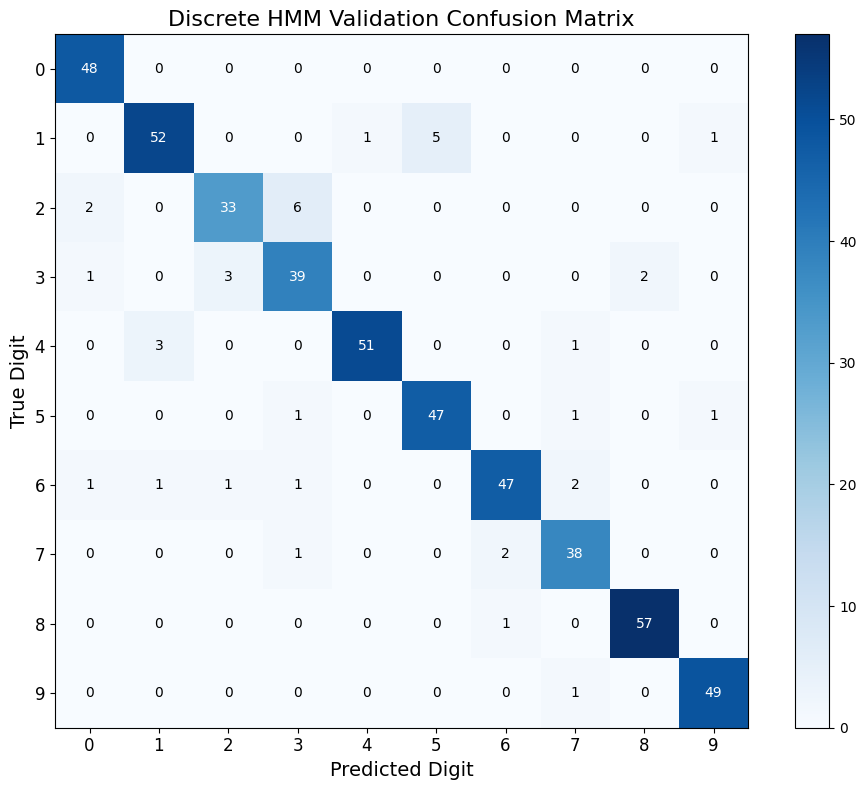

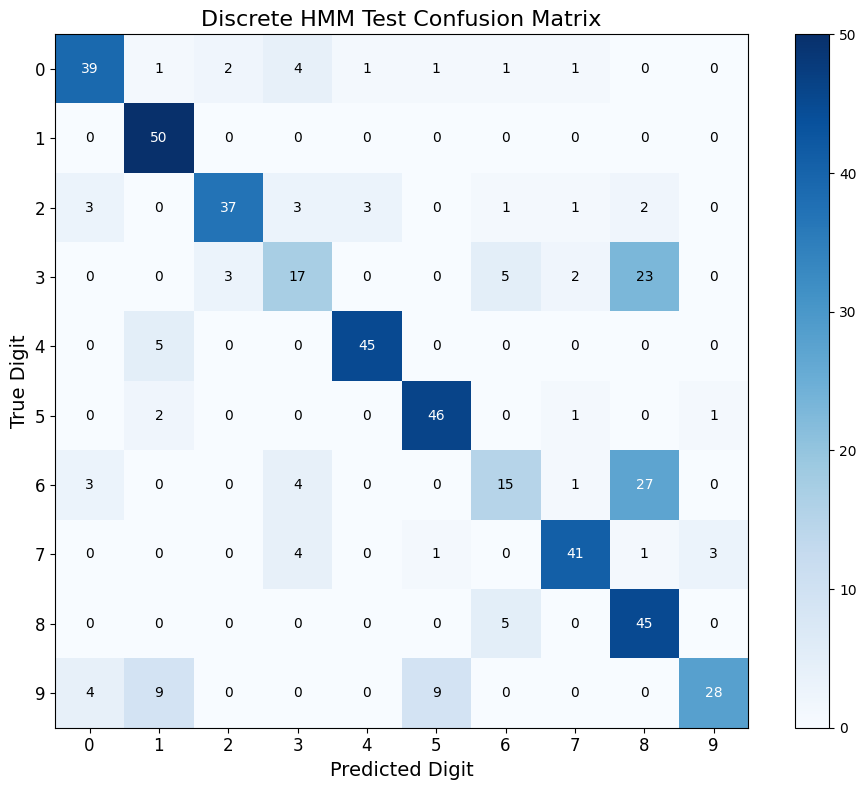

In [27]:
import matplotlib.pyplot as plt

def evaluate_vq(data_vq, predict_fn, models):
    true_labels = []
    predicted_labels = []
    for item in data_vq:
        true_labels.append(item["digit"])
        predicted_labels.append(predict_fn(item["sequence"], models))
    num_classes = 10
    conf_matrix = [[0] * num_classes for _ in range(num_classes)]
    for true, pred in zip(true_labels, predicted_labels):
        conf_matrix[true][pred] += 1
    correct = sum(1 for t, p in zip(true_labels, predicted_labels) if t == p)
    accuracy = correct / len(true_labels)
    return accuracy, conf_matrix


def plot_confusion_matrix(conf_matrix, title):
    cm = np.array(conf_matrix)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels([str(i) for i in range(10)], fontsize=12)
    ax.set_yticklabels([str(i) for i in range(10)], fontsize=12)
    ax.set_xlabel("Predicted Digit", fontsize=14)
    ax.set_ylabel("True Digit", fontsize=14)
    ax.set_title(title, fontsize=16)
    thresh = cm.max() / 2.0
    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()



dhmm_val_acc,  dhmm_val_cm  = evaluate_vq(val_vq,  predict_digit_dhmm, trained_dhmms)
dhmm_test_acc, dhmm_test_cm = evaluate_vq(test_vq, predict_digit_dhmm, trained_dhmms)

print("===== DISCRETE HMM RESULTS =====")
print(f"Validation Accuracy : {dhmm_val_acc  * 100:.2f}%")
print(f"Test Accuracy       : {dhmm_test_acc * 100:.2f}%")

print("\nPer-Digit Validation Accuracy:")
for digit in range(10):
    total = sum(dhmm_val_cm[digit])
    if total > 0:
        print(f"  Digit {digit}: {dhmm_val_cm[digit][digit] / total * 100:.2f}%")

print("\nPer-Digit Test Accuracy:")
for digit in range(10):
    total = sum(dhmm_test_cm[digit])
    if total > 0:
        print(f"  Digit {digit}: {dhmm_test_cm[digit][digit] / total * 100:.2f}%")


plot_confusion_matrix(dhmm_val_cm,  "Discrete HMM Validation Confusion Matrix")
plot_confusion_matrix(dhmm_test_cm, "Discrete HMM Test Confusion Matrix")